In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df = pd.read_csv("../data/processed/concrete_featured.csv")
df

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength,WaterCementRatio,TotalBinder,WaterBinderRatio,TotalAggregate,FineAggregateRatio,CoarseAggregateRatio,CementRatio,SCM,SCMPercentage,LogAge
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0.300000,540.0,0.300000,1716.0,0.393939,0.606061,1.000000,0.0,0.000000,3.367296
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0.300000,540.0,0.300000,1731.0,0.390526,0.609474,1.000000,0.0,0.000000,3.367296
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0.685714,475.0,0.480000,1526.0,0.389253,0.610747,0.700000,142.5,0.300000,5.602119
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0.685714,475.0,0.480000,1526.0,0.389253,0.610747,0.700000,142.5,0.300000,5.902633
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,0.966767,331.0,0.580060,1803.9,0.457620,0.542380,0.600000,132.4,0.400000,5.888878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28,0.649783,482.7,0.372074,1638.4,0.468933,0.531067,0.572612,206.3,0.427388,3.367296
1001,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18,0.608318,437.8,0.447693,1631.3,0.498621,0.501379,0.735952,115.6,0.264048,3.367296
1002,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70,1.297643,396.5,0.486003,1672.4,0.466396,0.533604,0.374527,248.0,0.625473,3.367296
1003,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77,1.103708,345.8,0.507808,1778.5,0.443576,0.556424,0.460093,186.7,0.539907,3.367296


# Linear Regression

In [3]:
# linear regression

# feature (X) and target (y)
X = df.drop(columns="CompressiveStrength")
y = df["CompressiveStrength"]

# split data into test and training dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=0)

# define model
lg = LinearRegression()
lg.fit(X_train, y_train)

# check score
print("Training score:",lg.score(X_train, y_train))
print("Test score",lg.score(X_test, y_test))

# check metrics
pred = lg.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2_lg = r2_score(y_test, pred)
mae_lg = mean_absolute_error(y_test, pred)
rmse_lg = root_mean_squared_error(y_test, pred)

Training score: 0.8459656774994779
Test score 0.816197643828279
MAE : 5.3847731651521205
RMSE: 7.018049248421728
R2  : 0.816197643828279


In [4]:
pd.Series(lg.coef_, index=X.columns).sort_values()    

CoarseAggregateRatio   -180.810344
WaterBinderRatio        -15.230865
WaterCementRatio        -13.451281
CementRatio             -13.404654
FineAggregate            -0.089657
Age                      -0.059334
FlyAsh                   -0.020796
SCM                      -0.007287
BlastFurnaceSlag          0.013508
TotalAggregate            0.020288
Water                     0.038239
TotalBinder               0.050939
Cement                    0.058226
CoarseAggregate           0.109945
Superplasticizer          0.158374
LogAge                   11.371191
SCMPercentage            13.404654
FineAggregateRatio      180.810344
dtype: float64

In [5]:
# Ridge

# feature (X) and target (y)
X = df.drop(columns="CompressiveStrength")
y = df["CompressiveStrength"]

# split data into test and training dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=0)

# define model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# check score
print("Training score:",ridge.score(X_train, y_train))
print("Test score",ridge.score(X_test, y_test))

# check metrics
pred = ridge.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)

Training score: 0.841392388299129
Test score 0.8128290584705423
MAE : 5.411423129463826
RMSE: 7.082067909088394
R2  : 0.8128290584705423


In [6]:
# lasso

# feature (X) and target (y)
X = df.drop(columns="CompressiveStrength")
y = df["CompressiveStrength"]

# split data into test and training dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=0)

# define model
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

# check score
print("Training score:",lasso.score(X_train, y_train))
print("Test score",lasso.score(X_test, y_test))

# check metrics
pred = lasso.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)

Training score: 0.8270904909113604
Test score 0.8011162778917528
MAE : 5.544605690985282
RMSE: 7.300296410589555
R2  : 0.8011162778917528


In [7]:
scores = cross_val_score(lg, X, y, cv=5, scoring="r2")
print(scores)
print(scores.mean())

[0.72376664 0.67011586 0.72128929 0.7756058  0.44572205]
0.6672999276158783


In [8]:
scores = cross_val_score(ridge, X, y, cv=5, scoring="r2")
print(scores)
print(scores.mean())

[0.73007788 0.67528771 0.72678318 0.83516557 0.41487941]
0.6764387510521648


# Random Forest Regressor

In [9]:
# make random forest regressor
# define target and feature
y = df["CompressiveStrength"]
X = df.drop(columns=["CompressiveStrength"])

# split data into test and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# define model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Train:", rf.score(X_train, y_train))
print("Test:", rf.score(X_test, y_test))

# check metrics
pred = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2_rf = r2_score(y_test, pred)
mae_rf = mean_absolute_error(y_test, pred)
rmse_rf = root_mean_squared_error(y_test, pred)

Train: 0.9842042984852637
Test: 0.9143308389401767
MAE : 3.4686995209750577
RMSE: 4.7646756791924245
R2  : 0.9143308389401767


In [10]:
# make random forest regressor
# define target and feature
y = df["CompressiveStrength"]
X = df.drop(columns=["CompressiveStrength"])

# split data into test and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# define model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

print("Train:", rf.score(X_train, y_train))
print("Test:", rf.score(X_test, y_test))

# check metrics
pred = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2_rf = r2_score(y_test, pred)
mae_rf = mean_absolute_error(y_test, pred)
rmse_rf = root_mean_squared_error(y_test, pred)

Train: 0.9729521518497748
Test: 0.9082165749327155
MAE : 3.6039786703504935
RMSE: 4.931774578195715
R2  : 0.9082165749327155


In [11]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
0.8867701775955187


In [12]:
best_rf = search.best_estimator_
print(best_rf.score(X_test, y_test))

r2_rscv = r2_score(y_test, pred)
mae_rscv = mean_absolute_error(y_test, pred)
rmse_rscv = root_mean_squared_error(y_test, pred)

0.9166980047389541


# Comparison Table

In [13]:
results = []

results.append({
    "Model": "Linear Regression",
    "R2": r2_lg,
    "MAE": mae_lg,
    "RMSE": rmse_lg
})

results.append({
    "Model": "Random Forest Regressor(Baseline)",
    "R2": r2_rf,
    "MAE": mae_rf,
    "RMSE": rmse_rf
})

results.append({
    "Model": "Random Forest Regressor(Tuned)",
    "R2": r2_rscv,
    "MAE": mae_rscv,
    "RMSE": rmse_rscv
})

In [14]:
comparison = pd.DataFrame(results)
comparison = comparison.round(3)
comparison

,Model,R2,MAE,RMSE
0,Linear Regression,0.816,5.385,7.018
1,Random Forest Regressor(Baseline),0.908,3.604,4.932
2,Random Forest Regressor(Tuned),0.908,3.604,4.932


In [15]:
comparison.sort_values(by="R2", ascending=False)

,Model,R2,MAE,RMSE
1,Random Forest Regressor(Baseline),0.908,3.604,4.932
2,Random Forest Regressor(Tuned),0.908,3.604,4.932
0,Linear Regression,0.816,5.385,7.018


# Evaluation Plot

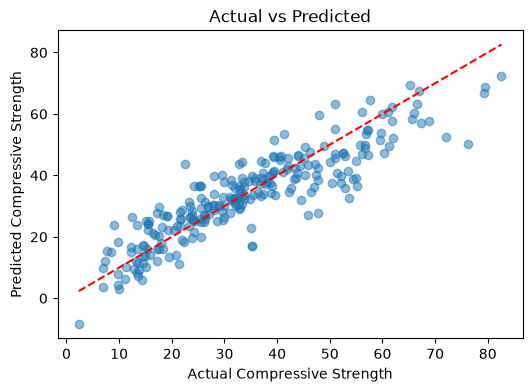

In [16]:
pred = lg.predict(X_test)

plt.figure(figsize=(6, 4))
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--")

plt.xlabel("Actual Compressive Strength")
plt.ylabel("Predicted Compressive Strength")
plt.title("Actual vs Predicted")
plt.show()

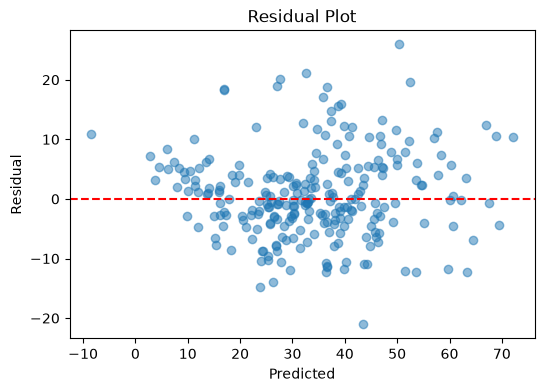

In [17]:
residual = y_test - pred

plt.figure(figsize=(6, 4))
plt.scatter(pred, residual, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

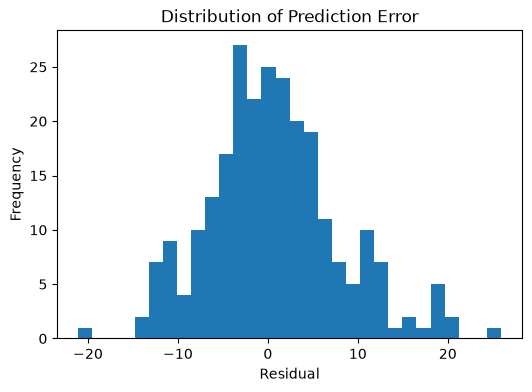

In [18]:
plt.figure(figsize=(6, 4))
plt.hist(residual, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Error")
plt.show()

In [19]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_}
)

importance = importance.sort_values(by="Importance", ascending=False)
importance

,Feature,Importance
10,WaterBinderRatio,0.380902
7,Age,0.190662
17,LogAge,0.187309
8,WaterCementRatio,0.077763
9,TotalBinder,0.040512
2,FlyAsh,0.024185
0,Cement,0.022874
4,Superplasticizer,0.010211
5,CoarseAggregate,0.009340
3,Water,0.008169


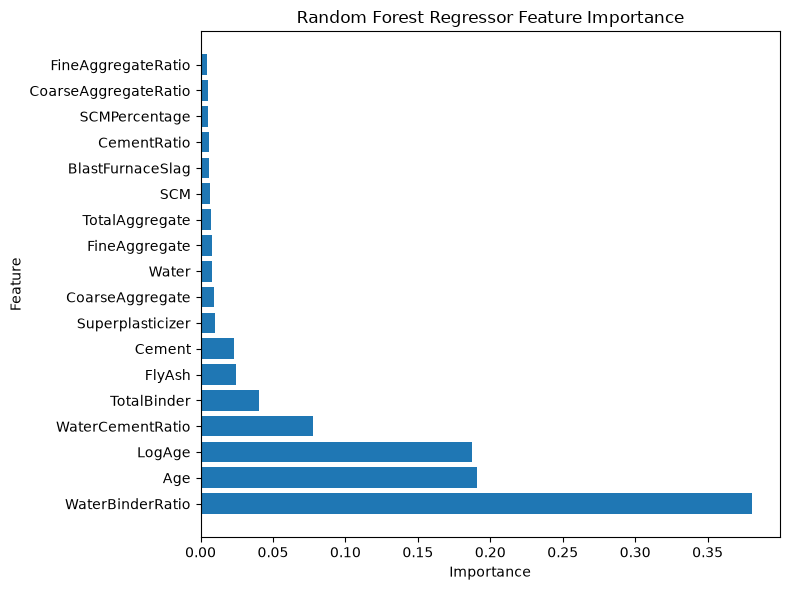

In [21]:
plt.figure(figsize=(8, 6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Random Forest Regressor Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Save The Best Model

In [22]:
joblib.dump(rf, "../models/concrete_strength_model.pkl")

['../models/concrete_strength_model.pkl']

# Conclusion
`RandomForestRegressor` outperformed `LinearRegression` with an R2 of 0.908.
Hyperparameter tuning using `RancomizedSearchCV` did not produce a meaningful improvement, Indicating that the baseline Random Forest already performed near its optimal configuration on this dataset.

`WaterBinderRatio` was the most influential feature in predicting concrete compressive strength, followed by `Age` and `LogAge`. This indicates that the cement content contributes the most to the model's predictions. 